# Baseline: TF-IDF into logistic regression

The bar the transformer has to clear.

In [1]:
import json
from collections import Counter
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

from model import BASELINE_PATH, METRICS_PATH
from model.baseline import MODEL_NAME, build_pipeline, fit, predict, save, top_terms
from model.data import LABELS, load_splits, prepare_split
from model.evaluate import evaluate, format_report, save_metrics

## Load and clean

In [2]:
splits = load_splits()
data = {name: prepare_split(splits, name, bow=True) for name in ("train", "validation", "test")}
for name, (texts, _) in data.items():
    print(f"{name:11s} {len(texts):6,} rows")

train_texts, train_labels = data["train"]
print()
print("example bag-of-words rows:")
for text in train_texts[:3]:
    print(" ", text[:88])

train       45,615 rows
validation   2,000 rows
test        12,284 rows

example bag-of-words rows:
  qt user in the original draft of the th book remus lupin survived the battle of hogwarts
  ben smith smith concussion remains out of the lineup thursday curtis nhl sj
  sorry bout the stream last night i crashed out but will be on tonight for sure then back


## Class balance

To guide against data skewness

In [3]:
counts = Counter(train_labels)
weights = compute_class_weight(
    "balanced", classes=np.array(sorted(LABELS)), y=np.array(train_labels)
)
for label_id in sorted(LABELS):
    share = counts[label_id] / len(train_labels) * 100
    name = LABELS[label_id]
    weight = weights[label_id]
    print(f"{name:9s} {counts[label_id]:6,}  {share:5.2f}%   weight {weight:.4f}")

negative   7,093  15.55%   weight 2.1437
neutral   20,673  45.32%   weight 0.7355
positive  17,849  39.13%   weight 0.8519


## The pipeline

In [4]:
pipeline = build_pipeline()
vectorizer = pipeline.named_steps["tfidf"]
classifier = pipeline.named_steps["logreg"]
print("TfidfVectorizer")
for key in (
    "ngram_range",
    "min_df",
    "max_df",
    "sublinear_tf",
    "max_features",
    "lowercase",
    "token_pattern",
):
    print(f"  {key:15s} {getattr(vectorizer, key)!r}")
print("LogisticRegression")
for key in ("solver", "C", "max_iter", "class_weight", "random_state"):
    print(f"  {key:15s} {getattr(classifier, key)!r}")

TfidfVectorizer
  ngram_range     (1, 2)
  min_df          2
  max_df          0.9
  sublinear_tf    True
  max_features    200000
  lowercase       False
  token_pattern   '\\b\\w+\\b'
LogisticRegression
  solver          'lbfgs'
  C               1.0
  max_iter        1000
  class_weight    'balanced'
  random_state    42


## Fit

In [5]:
started = perf_counter()
pipeline = fit(train_texts, train_labels)
elapsed = perf_counter() - started
vocabulary = len(pipeline.named_steps["tfidf"].vocabulary_)
print(f"fitted in {elapsed:.1f}s on {len(train_texts):,} rows")
print(f"vocabulary: {vocabulary:,} features")

fitted in 34.4s on 45,615 rows
vocabulary: 93,198 features


## Evaluate


In [6]:
reports = {}
for name in ("validation", "test"):
    texts, labels = data[name]
    reports[name] = evaluate(labels, predict(pipeline, texts), model_name=MODEL_NAME)
    print(f"=== {name} ===")
    print(format_report(reports[name]))
    print()

=== validation ===
tfidf-logreg  (2,000 samples)

class       precision     recall         f1   support
negative       0.4624     0.6699     0.5471       312
neutral        0.6950     0.6214     0.6561       869
positive       0.7562     0.7118     0.7333       819
macro          0.6378     0.6677     0.6455     2,000
weighted       0.6837     0.6660     0.6707     2,000

accuracy   0.6660

confusion (rows = true, columns = predicted)
            negative   neutral  positive
negative         209        71        32
neutral          173       540       156
positive          70       166       583



=== test ===
tfidf-logreg  (12,284 samples)

class       precision     recall         f1   support
negative       0.5616     0.6647     0.6088     3,972
neutral        0.6471     0.5710     0.6067     5,937
positive       0.5815     0.5739     0.5777     2,375
macro          0.5967     0.6032     0.5977    12,284
weighted       0.6067     0.6018     0.6017    12,284

accuracy   0.6018

confusion (rows = true, columns = predicted)
            negative   neutral  positive
negative       2,640     1,132       200
neutral        1,766     3,390       781
positive         295       717     1,363



## Confusion matrices

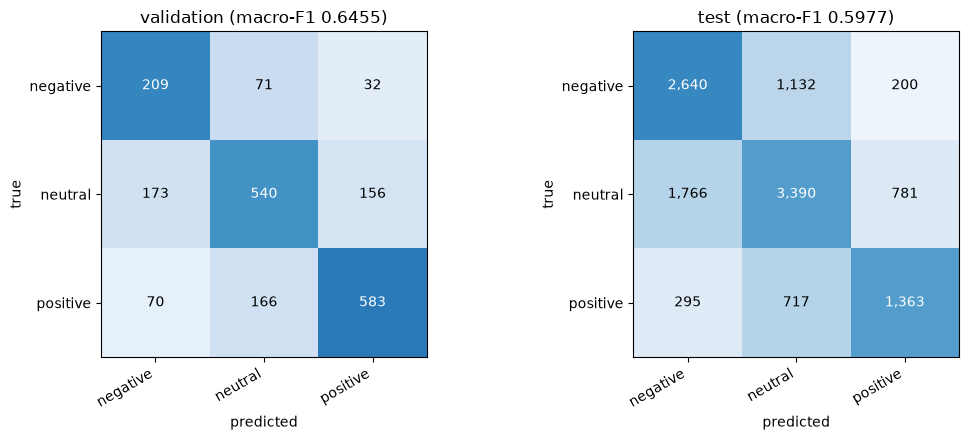

In [7]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
names = [LABELS[label_id] for label_id in sorted(LABELS)]
for axis, (split_name, report) in zip(axes, reports.items(), strict=True):
    matrix = report.confusion
    shares = matrix / matrix.sum(axis=1, keepdims=True)
    axis.imshow(shares, cmap="Blues", vmin=0, vmax=1)
    axis.set_title(f"{split_name} (macro-F1 {report.macro.f1:.4f})")
    axis.set_xticks(range(3), names, rotation=30, ha="right")
    axis.set_yticks(range(3), names)
    axis.set_xlabel("predicted")
    axis.set_ylabel("true")
    for row in range(3):
        for column in range(3):
            axis.text(
                column,
                row,
                f"{int(matrix[row][column]):,}",
                ha="center",
                va="center",
                color="white" if shares[row][column] > 0.5 else "black",
            )
plt.tight_layout()
plt.savefig("../../docs/assets/baseline_confusion.png", dpi=110, bbox_inches="tight")
plt.show()

## What the model learned


negative  fuck, t, not, shit, worst, sad, fucking, hate, stupid, sucks
neutral   gucci, shawn, do you, at, kane, murray, nirvana, milan, or, zayn
positive  happy, good, love, great, best, excited, amazing, t wait, awesome, fun


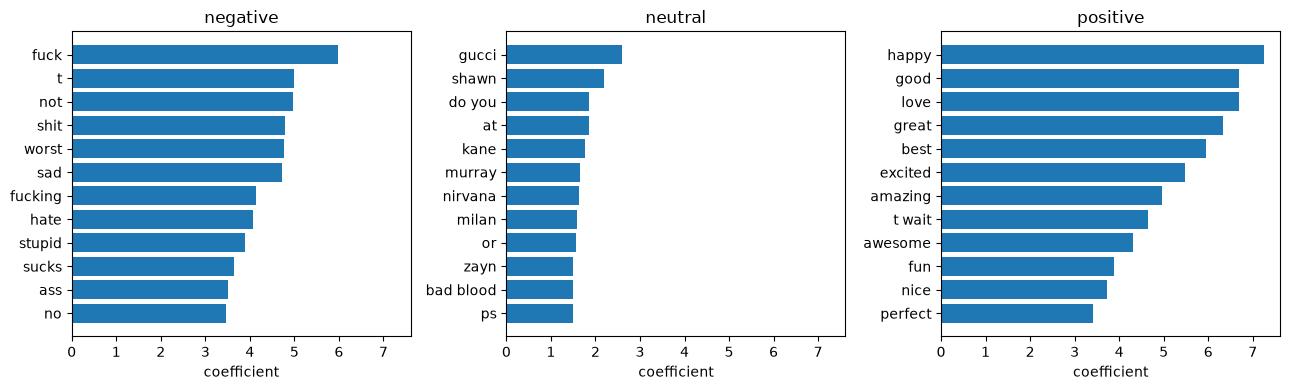

In [8]:
terms = {LABELS[label_id]: top_terms(pipeline, label_id, count=12) for label_id in sorted(LABELS)}
for name, ranked in terms.items():
    print(f"{name:9s}", ", ".join(term for term, _ in ranked[:10]))

figure, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True)
for axis, (name, ranked) in zip(axes, terms.items(), strict=True):
    words = [term for term, _ in ranked][::-1]
    scores = [weight for _, weight in ranked][::-1]
    axis.barh(np.arange(len(words)), scores)
    axis.set_yticks(np.arange(len(words)), words)
    axis.set_title(name)
    axis.set_xlabel("coefficient")
plt.tight_layout()
plt.savefig("../../docs/assets/baseline_terms.png", dpi=110, bbox_inches="tight")
plt.show()

## Save artifacts

In [9]:
save(pipeline, BASELINE_PATH)
save_metrics(
    METRICS_PATH,
    reports,
    model_name=MODEL_NAME,
    extra={"top_terms": terms},
)

size_mb = BASELINE_PATH.stat().st_size / 1_000_000
print(f"{BASELINE_PATH.name}  {size_mb:.1f} MB")
print(f"{METRICS_PATH.name}  {METRICS_PATH.stat().st_size:,} bytes")
print()
print("keys:", sorted(json.loads(METRICS_PATH.read_text())))
print("splits:", sorted(json.loads(METRICS_PATH.read_text())["splits"]))

baseline.joblib  5.9 MB
baseline.json  4,743 bytes

keys: ['labels', 'model_name', 'splits', 'top_terms']
splits: ['test', 'validation']


## Result

In [10]:
test_report = reports["test"]
print(f"model - {test_report.model_name}")
print(f"macro-F1 - {test_report.macro.f1:.4f}   <- the selector")
print(f"weighted - {test_report.weighted.f1:.4f}")
print(f"accuracy - {test_report.accuracy:.4f}")
print(f"validation macro-F1 {reports['validation'].macro.f1:.4f}")

model - tfidf-logreg
macro-F1 - 0.5977   <- the selector
weighted - 0.6017
accuracy - 0.6018
validation macro-F1 0.6455
